# RAG for NVDA NDocs

**Pipeline Overview:**
1. Exploratory Data Analysis
2. Data Preparation
3. Build Retrieval Indexes (BM25 + TF-IDF)
4. Feature Engineering
5. Train Ranking Models (Decision Tree, Random Forest, XGBoost, LambdaMART)
6. Evaluation & Comparison
7. End-to-End RAG Demo

## Stage 0: Setup & Install Dependencies

In [1]:
%pip install -q -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import random
import numpy as np

random.seed(42)
np.random.seed(42)

## Stage 1: EDA

In [3]:
from datasets import load_dataset

#load dataset
dataset = load_dataset("nvidia/Retrieval-Synthetic-NVDocs-v1")

print(dataset)

c:\Users\sidagarwal\OneDrive - Microsoft\Documents\GitHub\Applied-Machine-Learning\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\sidagarwal\OneDrive - Microsoft\Documents\GitHub\Applied-Machine-Learning\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\sidagarwal\.cache\huggingface\hub\datasets--nvidia--Retrieval-Synthetic-NVDocs-v1. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support

DatasetDict({
    train: Dataset({
        features: ['file_name', 'text', 'chunks', 'sections_structured', 'bundle_id', 'bundle_members', 'is_multi_doc', 'document_artifacts', 'qa_generation', 'deduplicated_qa_pairs', 'qa_evaluations'],
        num_rows: 15095
    })
})


In [4]:
display(dataset['train'][0])

{'file_name': ['researchnvidiacom/research.nvidia.com_publication_2022-11_demystifying-map-space-exploration-npus'],
 'text': 'Map Space Exploration is the problem of finding optimized mappings of a Deep Neural Network (DNN) model on an accelerator. It is known to be extremely computationally expensive, and there has been active research looking at both heuristics and learning-based methods to make the problem computationally tractable. However, while there are dozens of mappers out there (all empirically claiming to find better mappings than others), the research community lacks systematic insights on how different search techniques navigate the map-space and how different mapping axes contribute to the accelerator’s performance and efficiency. Such insights are crucial to developing mapping frameworks for emerging DNNs that are increasingly irregular (due to neural architecture search) and sparse, making the corresponding map spaces much more complex. In this work, rather than propos

In [5]:
from datasets import DatasetDict

full_dataset = dataset['train']

train_testval = full_dataset.train_test_split(test_size=0.2, seed=42)

In [6]:
#split test_val into validation (10%) and test (10%)
test_val = train_testval['test'].train_test_split(test_size=0.5, seed=42)

In [7]:
#build DatasetDict
split_dataset = DatasetDict({
    'train': train_testval['train'],
    'validation': test_val['train'],
    'test': test_val['test']
})

In [8]:
print(split_dataset)

DatasetDict({
    train: Dataset({
        features: ['file_name', 'text', 'chunks', 'sections_structured', 'bundle_id', 'bundle_members', 'is_multi_doc', 'document_artifacts', 'qa_generation', 'deduplicated_qa_pairs', 'qa_evaluations'],
        num_rows: 12076
    })
    validation: Dataset({
        features: ['file_name', 'text', 'chunks', 'sections_structured', 'bundle_id', 'bundle_members', 'is_multi_doc', 'document_artifacts', 'qa_generation', 'deduplicated_qa_pairs', 'qa_evaluations'],
        num_rows: 1509
    })
    test: Dataset({
        features: ['file_name', 'text', 'chunks', 'sections_structured', 'bundle_id', 'bundle_members', 'is_multi_doc', 'document_artifacts', 'qa_generation', 'deduplicated_qa_pairs', 'qa_evaluations'],
        num_rows: 1510
    })
})


In [9]:
import pandas as pd
import matplotlib.pyplot as plt

#train split to DataFrame
df = split_dataset['train'].to_pandas()

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12076 entries, 0 to 12075
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   file_name              12076 non-null  object
 1   text                   12076 non-null  str   
 2   chunks                 12076 non-null  object
 3   sections_structured    12076 non-null  object
 4   bundle_id              12076 non-null  str   
 5   bundle_members         12076 non-null  object
 6   is_multi_doc           12076 non-null  bool  
 7   document_artifacts     12076 non-null  object
 8   qa_generation          12076 non-null  object
 9   deduplicated_qa_pairs  12076 non-null  object
 10  qa_evaluations         12076 non-null  object
dtypes: bool(1), object(8), str(2)
memory usage: 59.7+ MB


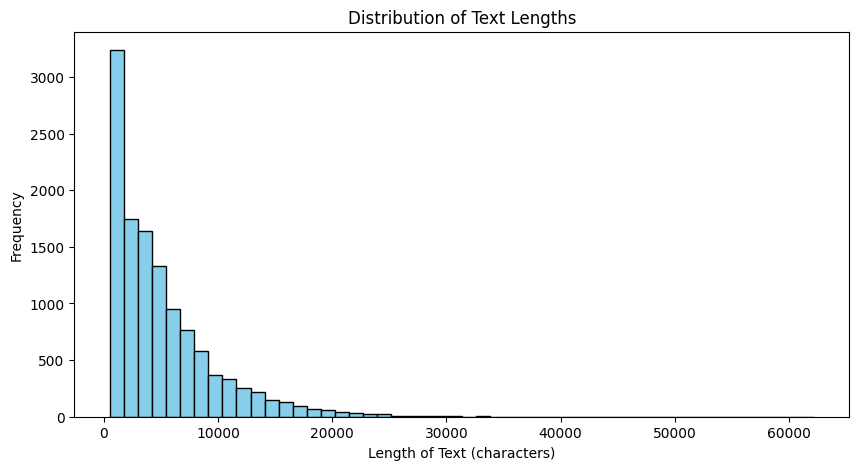

In [11]:
#text length distribution
df['text_length'] = df['text'].apply(lambda x: len(str(x)))

plt.figure(figsize=(10, 5))
plt.hist(df['text_length'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Text Lengths')
plt.xlabel('Length of Text (characters)')
plt.ylabel('Frequency')
plt.show()

In [12]:
#is_multi_doc distribution
if 'is_multi_doc' in df.columns:
    print(df['is_multi_doc'].value_counts())

is_multi_doc
False    12076
Name: count, dtype: int64


### Deep dive: Understand the QA-Chunk mapping

Each document has chunks and QA pairs. Each QA pair's `segment_ids` tells us which chunks are relevant.
This is our **golden label**

In [13]:
#single document structure
record = split_dataset['train'][0]

print(f"File: {record['file_name']}")
print(f"Number of chunks: {len(record['chunks'])}")
print(f"Number of QA pairs: {len(record['deduplicated_qa_pairs'])}")

File: ['researchnvidiacom/research.nvidia.com_publication_2022-03_gatspi-gpu-accelerated-gate-level-simulation-power-improvement']
Number of chunks: 1
Number of QA pairs: 7


In [14]:
#first QA pair details
qa = record['deduplicated_qa_pairs'][0]
print(f"Question: {qa['question']}")
print(f"Answer: {qa['answer'][:200]}...")
print(f"Query Type: {qa['query_type']}")
print(f"Reasoning Type: {qa['reasoning_type']}")
print(f"Complexity: {qa['question_complexity']}")
print(f"Hop Count: {qa['hop_count']}")
print(f"Relevant Segment IDs: {qa['segment_ids']}")

Question: How does the utilization of GPU acceleration in GATSPI contribute to its significant speedup over commercial simulators, and what role do custom CUDA kernels play in this process?
Answer: GATSPI leverages GPU acceleration through custom CUDA kernels in PyTorch, enabling a simulation kernel speedup of up to 1668X on a single-GPU system and 7412X on multiple-GPU systems compared to comme...
Query Type: multi_hop
Reasoning Type: factual
Complexity: 5
Hop Count: 1
Relevant Segment IDs: [1]


In [15]:
#relevant chunks preview
chunk_lookup = {c['chunk_id']: c for c in record['chunks']}
for sid in qa['segment_ids']:
    if sid in chunk_lookup:
        c = chunk_lookup[sid]
        print(f"\nChunk ID: {sid}")
        print(f"Text preview: {c['text'][:300]}...")
        print(f"Word count: {c['word_count']}, Sentence count: {c['sentence_count']}")


Chunk ID: 1
Text preview: In this paper, we present GATSPI, a novel GPU accelerated logic gate simulator that enables ultra-fast power estimation for industry sized ASIC designs with millions of gates.. GATSPI is written in PyTorch with custom CUDA kernels for ease of coding and maintainability.. It achieves simulation kerne...
Word count: 140, Sentence count: 5


## Stage 2: Data Preparation

We extract all chunks and QA pairs, then create training triples:
- **Positive**: (question, relevant_chunk, 1) — chunk is in `segment_ids`
- **Negative**: (question, random_chunk, 0) — sampled from other chunks

In [16]:
from data_prep import extract_all_chunks, extract_qa_pairs, create_relevance_triples

#extract train chunks and QA pairs
train_chunks = extract_all_chunks(split_dataset['train'])
train_qa = extract_qa_pairs(split_dataset['train'])
print(f"Train: {len(train_chunks)} chunks, {len(train_qa)} QA pairs")

Extracting QA pairs: 100%|██████████| 12076/12076 [00:26<00:00, 463.79it/s]

Train: 96442 chunks, 84485 QA pairs


In [17]:
#extract validation chunks and QA pairs
val_chunks = extract_all_chunks(split_dataset['validation'])
val_qa = extract_qa_pairs(split_dataset['validation'])
print(f"Val: {len(val_chunks)} chunks, {len(val_qa)} QA pairs")

Extracting QA pairs: 100%|██████████| 1509/1509 [00:03<00:00, 474.70it/s]

Val: 12274 chunks, 10560 QA pairs


In [18]:
#extract test chunks and QA pairs
test_chunks = extract_all_chunks(split_dataset['test'])
test_qa = extract_qa_pairs(split_dataset['test'])
print(f"Test: {len(test_chunks)} chunks, {len(test_qa)} QA pairs")

Extracting QA pairs: 100%|██████████| 1510/1510 [00:03<00:00, 473.18it/s]

Test: 12162 chunks, 10561 QA pairs


In [19]:
#global chunk pool for retrieval
all_chunks = train_chunks + val_chunks + test_chunks
print(f"Total chunks in corpus: {len(all_chunks)}")

Total chunks in corpus: 120878


In [20]:
#create train triples
train_triples = create_relevance_triples(train_qa, all_chunks, neg_per_positive=4, seed=42)
print(f"Train triples: {len(train_triples)} ({train_triples['relevance'].sum()} pos, {(train_triples['relevance']==0).sum()} neg)")

Creating triples: 100%|██████████| 84485/84485 [00:02<00:00, 30009.63it/s]


Train triples: 961150 (191978 pos, 769172 neg)


In [21]:
#create validation triples
val_triples = create_relevance_triples(val_qa, all_chunks, neg_per_positive=4, seed=42)
print(f"Val triples: {len(val_triples)} ({val_triples['relevance'].sum()} pos, {(val_triples['relevance']==0).sum()} neg)")

Creating triples: 100%|██████████| 10560/10560 [00:00<00:00, 31611.25it/s]


Val triples: 121119 (24211 pos, 96908 neg)


In [22]:
#sanity check triples
#positive
pos = train_triples[train_triples['relevance'] == 1].iloc[0]
print(f"Question: {pos['question'][:100]}...")
print(f"Chunk: {pos['chunk_text'][:100]}...")
print(f"Relevance: {pos['relevance']}")

#negative
neg = train_triples[train_triples['relevance'] == 0].iloc[0]
print(f"Question: {neg['question'][:100]}...")
print(f"Chunk: {neg['chunk_text'][:100]}...")
print(f"Relevance: {neg['relevance']}")

Question: How does the utilization of GPU acceleration in GATSPI contribute to its significant speedup over co...
Chunk: ---
license: other
license_name: nvidia-open-model-license
license_link: >-
  https://www.nvidia.com...
Relevance: 1
Question: How does the utilization of GPU acceleration in GATSPI contribute to its significant speedup over co...
Chunk: Variant calling runtimes for CPU versus GPU.. Image provided by NYU Langone Health
Data provided by ...
Relevance: 0


## Stage 3: Build Retrieval Indexes

We build two indexes over the **entire corpus** of chunks:

1. **BM25** (sparse, lexical): Scores based on token overlap
2. **TF-IDF** (sparse, semantic): Uses sklearn's TfidfVectorizer + cosine similarity. Captures term importance.

These scores become **features** for our RAG Models.

In [23]:
from retrieval import BM25Index, TfidfIndex

#prepare corpus texts and IDs
corpus_texts = [c['chunk_text'] for c in all_chunks]
corpus_ids = [c['chunk_id'] for c in all_chunks]
print(f"Corpus size: {len(corpus_texts)} chunks")

Corpus size: 120878 chunks


In [24]:
#build BM25 index
bm25_index = BM25Index(corpus_texts, corpus_ids)

BM25 index built: 120878 docs, 110482 terms (sparse matrix)


In [25]:
#build TF-IDF index
tfidf_index = TfidfIndex(max_features=50000, ngram_range=(1, 2))
tfidf_index.build_index(corpus_texts, corpus_ids)

Building TF-IDF index over 120878 chunks...
TF-IDF index built: 120878 docs, 50000 features


In [26]:
#test retrieval top-5
sample_q = train_qa[0]['question']
print(f"Query: {sample_q}\n")

for chunk_id, score in bm25_index.top_k(sample_q, k=5):
    print(f"  {chunk_id}: score={score:.4f}")

for chunk_id, score in tfidf_index.top_k(sample_q, k=5):
    print(f"  {chunk_id}: score={score:.4f}")

#check golden chunk in results
golden_ids = set(train_qa[0]['segment_ids'])
print(f"\nGolden chunk IDs: {golden_ids}")

Query: How does the utilization of GPU acceleration in GATSPI contribute to its significant speedup over commercial simulators, and what role do custom CUDA kernels play in this process?

  0_1: score=45.2301
  8142_4: score=32.4650
  2987_16: score=29.3795
  5201_1: score=28.2134
  326_2: score=28.1439
  4819_3: score=0.2539
  845_19: score=0.2449
  576_11: score=0.2387
  3077_4: score=0.1960
  9294_7: score=0.1843

Golden chunk IDs: {'0_1'}


## Stage 4: Feature Engineering

For each (question, chunk) pair, we compute a feature vector:

| Feature | Type | Source |
|---------|------|--------|
| `bm25_score` | Numeric | BM25 index |
| `cosine_similarity` | Numeric | TF-IDF cosine similarity |
| `token_overlap_ratio` | Numeric | Text overlap |
| `token_overlap_count` | Numeric | Text overlap |
| `question_length` | Numeric | Question metadata |
| `chunk_word_count` | Numeric | Chunk metadata |
| `chunk_sentence_count` | Numeric | Chunk metadata |
| `question_complexity` | Numeric | QA metadata |
| `hop_count` | Numeric | QA metadata |
| `qtype_*` | One-hot | Query type |
| `rtype_*` | One-hot | Reasoning type |

The ranking models will learn which combinations of these features predict relevance.

In [27]:
from features import compute_features, get_feature_columns

#compute train features
train_featured = compute_features(train_triples, bm25_index, tfidf_index)
print(f"\nTrain shape: {train_featured.shape}")

Computing features for 961150 pairs (84474 unique questions)...
BM25 scoring (pair-wise)...
  BM25 scores computed: (961150,)
TF-IDF scoring (pair-wise)...
  TF-IDF scores computed: (961150,)
Computing text overlap features...

Train shape: (961150, 26)


In [28]:
#inspect features
feature_cols = get_feature_columns(train_featured)
print(f"Feature columns ({len(feature_cols)}):")
for col in feature_cols:
    print(f"  - {col}")

train_featured[feature_cols].describe().round(3)

Feature columns (19):
  - question_complexity
  - hop_count
  - chunk_word_count
  - chunk_sentence_count
  - bm25_score
  - cosine_similarity
  - token_overlap_ratio
  - token_overlap_count
  - question_length
  - qtype_contextual
  - qtype_multi_hop
  - qtype_structural
  - rtype_causal
  - rtype_factual
  - rtype_inferential
  - rtype_procedural
  - rtype_relational
  - rtype_temporal
  - rtype_visual


,question_complexity,hop_count,chunk_word_count,chunk_sentence_count,bm25_score,cosine_similarity,token_overlap_ratio,token_overlap_count,question_length
count,961150.000,961150.000,961150.000,961150.000,961150.000,961150.000,961150.000,961150.000,961150.000
mean,4.913,1.827,96.308,4.754,9.588,0.037,0.206,4.868,26.878
std,0.281,0.920,58.319,0.820,13.126,0.082,0.110,2.728,5.915
min,4.000,1.000,1.000,1.000,0.000,0.000,0.000,0.000,10.000
25%,5.000,1.000,67.000,5.000,2.485,0.000,0.139,3.000,23.000
50%,5.000,2.000,94.000,5.000,4.873,0.003,0.200,5.000,26.000
75%,5.000,3.000,120.000,5.000,9.308,0.020,0.261,6.000,31.000
max,5.000,7.000,4964.000,5.000,137.827,0.792,0.826,36.000,63.000


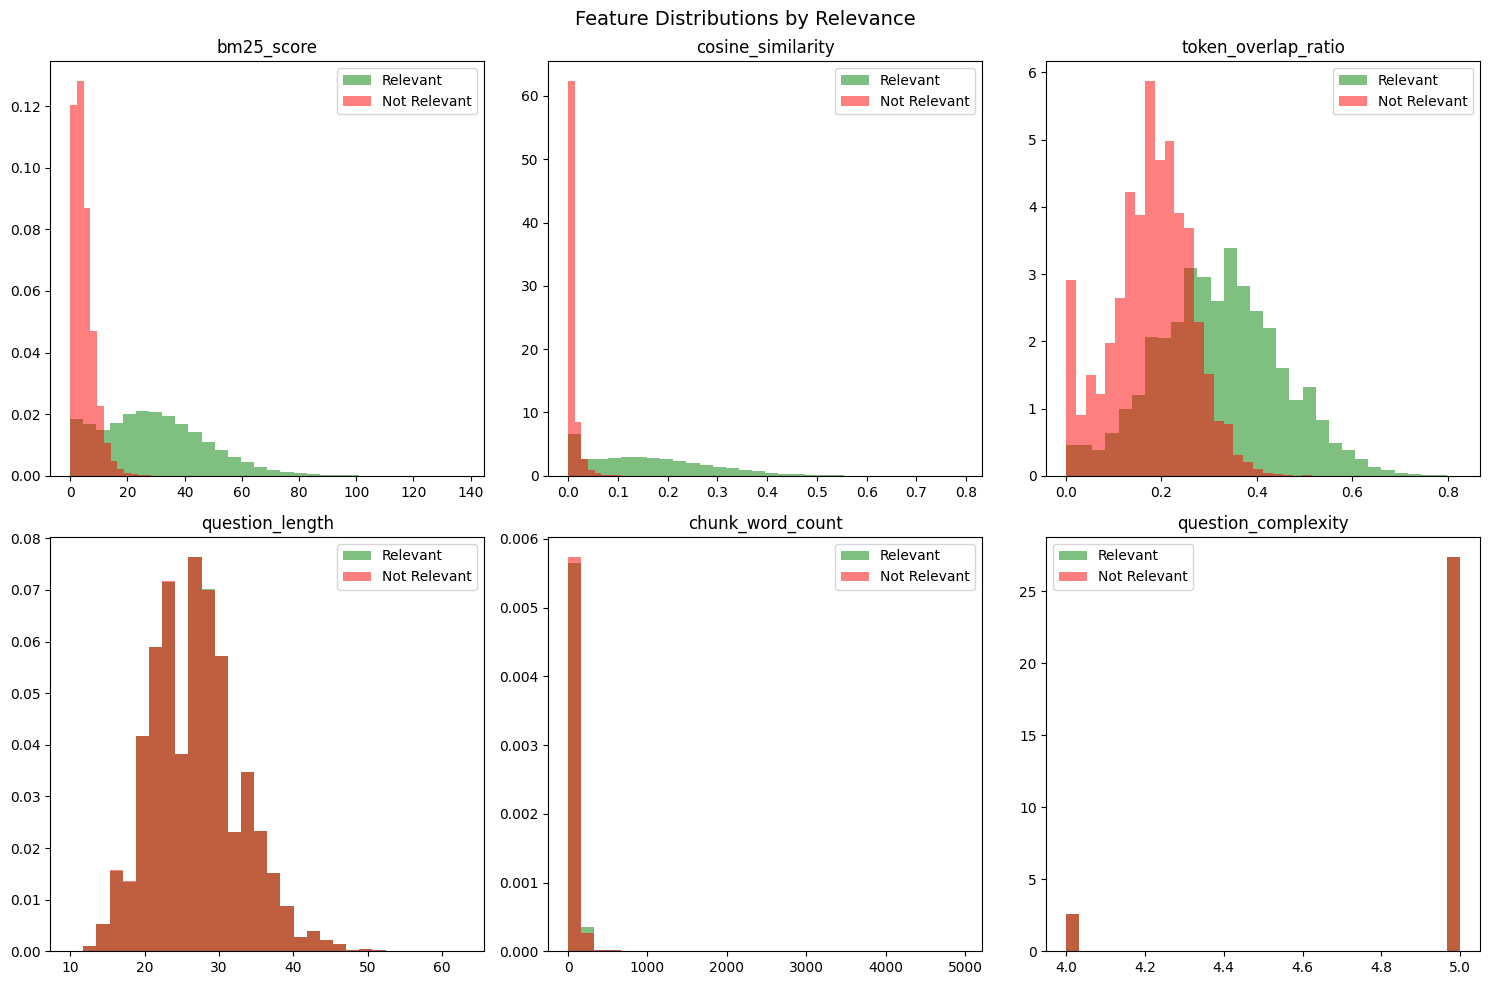

In [29]:
import seaborn as sns

#feature distributions by relevance
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
key_features = ['bm25_score', 'cosine_similarity', 'token_overlap_ratio',
                'question_length', 'chunk_word_count', 'question_complexity']

for ax, feat in zip(axes.flat, key_features):
    for rel, color, label in [(1, 'green', 'Relevant'), (0, 'red', 'Not Relevant')]:
        subset = train_featured[train_featured['relevance'] == rel][feat]
        ax.hist(subset, bins=30, alpha=0.5, color=color, label=label, density=True)
    ax.set_title(feat)
    ax.legend()

plt.suptitle('Feature Distributions by Relevance', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier as _RFC

#quick RF for feature importance analysis
_rf_importance = _RFC(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
_rf_importance.fit(train_featured[feature_cols].values, train_featured['relevance'].values)

importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': _rf_importance.feature_importances_
}).sort_values('importance', ascending=False)

print("Feature Importance (Random Forest):\n")
print(importance_df.to_string(index=False))

In [ ]:
#visualize
fig, ax = plt.subplots(figsize=(10, 6))
importance_df.plot(x='feature', y='importance', kind='barh', ax=ax, legend=False)
ax.invert_yaxis()
ax.set_title('Feature Importance (Random Forest)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

In [ ]:
#identify low-importance features to drop
drop_threshold = 0.01
low_importance = importance_df[importance_df['importance'] < drop_threshold]['feature'].tolist()
print(f"\nFeatures below {drop_threshold} threshold (candidates to drop):")
for f in low_importance:
    print(f"  - {f}")

## Stage 5: Train Ranking Models

We train multiple models to predict relevance scores, then rank chunks by score.

**Models:**
1. **BM25 Baseline** — no training, just use BM25 scores directly
2. **TF-IDF Baseline** — no training, just use TF-IDF cosine similarity
3. **Decision Tree** — simple tree-based classifier
4. **Random Forest** — ensemble of trees
5. **XGBoost Ranker** — gradient-boosted trees with ranking objective (LambdaMART)
6. **LightGBM Ranker** — alternative LambdaMART implementation

For the tree models, we train a binary classifier (relevant vs not) and use `predict_proba` as the ranking score.
For XGBoost/LightGBM, we use their native ranking objectives which optimize NDCG directly.

In [30]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from evaluate import print_evaluation

In [31]:
#compute validation features
val_featured = compute_features(val_triples, bm25_index, tfidf_index)
print(f"Val shape: {val_featured.shape}")

Computing features for 121119 pairs (10560 unique questions)...
BM25 scoring (pair-wise)...
  BM25 scores computed: (121119,)
TF-IDF scoring (pair-wise)...
  TF-IDF scores computed: (121119,)
Computing text overlap features...
Val shape: (121119, 26)


In [ ]:
#prepare feature matrices — drop low-importance qtype/rtype one-hot features
drop_features = [c for c in feature_cols if c.startswith('qtype_') or c.startswith('rtype_')]
feature_cols = [c for c in feature_cols if c not in drop_features]
print(f"Dropped {len(drop_features)} low-importance features: {drop_features}")
print(f"Keeping {len(feature_cols)} features: {feature_cols}\n")

#align feature columns across splits
for col in feature_cols:
    if col not in val_featured.columns:
        val_featured[col] = 0

X_train = train_featured[feature_cols].values
y_train = train_featured['relevance'].values
X_val = val_featured[feature_cols].values
y_val = val_featured['relevance'].values

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}")

X_train: (961150, 19), X_val: (121119, 19)


### 5a. Precompute Validation Candidates & Baselines

We retrieve candidates from the **full corpus** once, then score with every model cheaply.
BM25 and TF-IDF baselines use the raw retrieval scores — no training needed.

In [33]:
from evaluate import prepare_candidates, evaluate_from_candidates

#chunk lookup for full-corpus eval
chunk_lookup = {c['chunk_id']: c for c in all_chunks}

#precompute val candidates + features
print("Precomputing val candidates (BM25 ∪ TF-IDF top-100)...")
val_candidates = prepare_candidates(val_qa, bm25_index, tfidf_index,
                                     chunk_lookup, feature_cols, candidate_k=100)
print(f"Done. {len(val_candidates)} questions, avg {np.mean([c['metadata']['n_candidates'] for c in val_candidates]):.0f} candidates each")

Precomputing val candidates (BM25 ∪ TF-IDF top-100)...
  Batch BM25 scoring 10560 unique questions...
  Batch TF-IDF scoring 10560 unique questions...
  Computing BM25 score matrix (batch)...
  Computing TF-IDF score matrix (batch)...


Preparing candidates: 100%|██████████| 10560/10560 [07:59<00:00, 22.03it/s]


Done. 10560 questions, avg 154 candidates each


In [34]:
#BM25 baseline on validation 
bm25_val_metrics, _ = evaluate_from_candidates(val_candidates, model=None)
print_evaluation(bm25_val_metrics, "BM25 Baseline (Val)")

#TF-IDF baseline on validation
tfidf_val_metrics, _ = evaluate_from_candidates(val_candidates, model='tfidf')
print_evaluation(tfidf_val_metrics, "TF-IDF Cosine Similarity Baseline (Val)")


  BM25 Baseline (Val) Evaluation Results
  MAP            : 0.0962
  MRR            : 0.1360
  NDCG@10        : 0.1073
  NDCG@20        : 0.1137
  NDCG@5         : 0.0988
  Recall@10      : 0.1049
  Recall@20      : 0.1210
  Recall@5       : 0.0880

  TF-IDF Cosine Similarity Baseline (Val) Evaluation Results
  MAP            : 0.0729
  MRR            : 0.1035
  NDCG@10        : 0.0820
  NDCG@20        : 0.0896
  NDCG@5         : 0.0723
  Recall@10      : 0.0885
  Recall@20      : 0.1077
  Recall@5       : 0.0687


### 5b. Decision Tree Classifier

In [35]:
#train decision tree
dt_model = DecisionTreeClassifier(max_depth=10, min_samples_leaf=20, random_state=42)
dt_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [36]:
#evaluate decision tree on validation 
dt_val_metrics, _ = evaluate_from_candidates(val_candidates, dt_model)
print_evaluation(dt_val_metrics, "Decision Tree (Val)")

dt_importance = pd.Series(dt_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(dt_importance.head(10))


  Decision Tree (Val) Evaluation Results
  MAP            : 0.0536
  MRR            : 0.0702
  NDCG@10        : 0.0616
  NDCG@20        : 0.0729
  NDCG@5         : 0.0469
  Recall@10      : 0.0817
  Recall@20      : 0.1111
  Recall@5       : 0.0516
cosine_similarity       0.967236
bm25_score              0.021871
question_length         0.004327
chunk_word_count        0.002552
token_overlap_count     0.002344
chunk_sentence_count    0.000586
token_overlap_ratio     0.000583
hop_count               0.000167
rtype_relational        0.000061
rtype_temporal          0.000055
dtype: float64


### 5c. Random Forest Classifier

In [37]:
#train random forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [ ]:
#evaluate random forest on validation
rf_val_metrics, _ = evaluate_from_candidates(val_candidates, rf_model)
print_evaluation(rf_val_metrics, "Random Forest (Val)")

rf_importance = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(rf_importance.head(10))

### 5d. XGBoost Ranker (LambdaMART)

XGBoost's `rank:ndcg` objective directly optimizes NDCG — the key ranking metric.
It needs a `group` parameter telling it which rows belong to the same query.

In [ ]:
import xgboost as xgb

#sort by question for group-based ranking
train_sorted = train_featured.sort_values('question').reset_index(drop=True)
val_sorted = val_featured.sort_values('question').reset_index(drop=True)

train_groups = train_sorted.groupby('question').size().values
val_groups = val_sorted.groupby('question').size().values

X_train_sorted = train_sorted[feature_cols].values
y_train_sorted = train_sorted['relevance'].values
X_val_sorted = val_sorted[feature_cols].values
y_val_sorted = val_sorted['relevance'].values

In [ ]:
#train XGBoost ranker
xgb_model = xgb.XGBRanker(
    objective='rank:ndcg',
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    min_child_weight=10,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method='hist',
)

xgb_model.fit(
    X_train_sorted, y_train_sorted,
    group=train_groups,
    eval_set=[(X_val_sorted, y_val_sorted)],
    eval_group=[val_groups],
    verbose=50
)

In [ ]:
#evaluate XGBoost on validation (full-corpus)
xgb_val_metrics, _ = evaluate_from_candidates(val_candidates, xgb_model)
print_evaluation(xgb_val_metrics, "XGBoost Ranker (Val)")

### 5e. LightGBM Ranker (LambdaMART)

In [ ]:
import lightgbm as lgb

#train LightGBM ranker
lgb_model = lgb.LGBMRanker(
    objective='lambdarank',
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1,
)

lgb_model.fit(
    X_train_sorted, y_train_sorted,
    group=train_groups,
    eval_set=[(X_val_sorted, y_val_sorted)],
    eval_group=[val_groups],
    eval_at=[5, 10, 20],
)

In [ ]:
#evaluate LightGBM on validation (full-corpus)
lgb_val_metrics, _ = evaluate_from_candidates(val_candidates, lgb_model)
print_evaluation(lgb_val_metrics, "LightGBM Ranker (Val)")

## Stage 6: Model Comparison & Final Test Evaluation

Compare all models side-by-side on validation, pick the best, then do final evaluation on the held-out test set.

In [ ]:
#validation metrics comparison
all_val_metrics = {
    'BM25 Baseline': bm25_val_metrics,
    'TF-IDF Cosine': tfidf_val_metrics,
    'Decision Tree': dt_val_metrics,
    'Random Forest': rf_val_metrics,
    'XGBoost Ranker': xgb_val_metrics,
    'LightGBM Ranker': lgb_val_metrics,
}

comparison_df = pd.DataFrame(all_val_metrics).T
comparison_df = comparison_df.round(4)
display(comparison_df)

In [ ]:
#visualize model comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics_to_plot = ['NDCG@10', 'Recall@10', 'MRR']
for ax, metric in zip(axes, metrics_to_plot):
    values = comparison_df[metric].sort_values(ascending=True)
    colors = ['#2ecc71' if v == values.max() else '#3498db' for v in values]
    values.plot(kind='barh', ax=ax, color=colors)
    ax.set_title(metric, fontsize=14)
    ax.set_xlabel('Score')
    for i, v in enumerate(values):
        ax.text(v + 0.005, i, f'{v:.4f}', va='center')

plt.suptitle('Model Comparison on Validation Set', fontsize=16)
plt.tight_layout()
plt.show()

### Final Test Evaluation (Full-Corpus Retrieval)

For each test question, we retrieve **top-100 candidates from BM25 ∪ top-100 from TF-IDF**, then re-rank with the best model. Metrics are computed over this realistic candidate pool (~150-200 chunks per question)

In [ ]:
#precompute test candidates + features ONCE
test_candidates = prepare_candidates(test_qa, bm25_index, tfidf_index,
                                      chunk_lookup, feature_cols, candidate_k=100)
print(f"Done. {len(test_candidates)} questions, avg {np.mean([c['metadata']['n_candidates'] for c in test_candidates]):.0f} candidates each")

In [ ]:
#best model by val NDCG@10
best_model_name = comparison_df['NDCG@10'].idxmax()
print(f"Best model (by Val NDCG@10): {best_model_name}")

In [ ]:
#select best model
model_objects = {
    'Decision Tree': dt_model,
    'Random Forest': rf_model,
    'XGBoost Ranker': xgb_model,
    'LightGBM Ranker': lgb_model,
}
best_model_obj = model_objects[best_model_name]

In [ ]:
#evaluate BM25 baseline 
bm25_test_metrics, bm25_meta = evaluate_from_candidates(test_candidates, model=None)
print_evaluation(bm25_test_metrics, "BM25 Baseline (Test)")

In [ ]:
#evaluate TF-IDF baseline 
tfidf_test_metrics, tfidf_meta = evaluate_from_candidates(test_candidates, model='tfidf')
print_evaluation(tfidf_test_metrics, "TF-IDF Baseline (Test)")

In [ ]:
#evaluate best model 
print(f"Evaluating {best_model_name}...")
best_test_metrics, best_meta = evaluate_from_candidates(test_candidates, best_model_obj)
print_evaluation(best_test_metrics, f"{best_model_name} (Test)")

In [ ]:
#side-by-side comparison
test_comparison_df = pd.DataFrame({
    'BM25 Baseline': bm25_test_metrics,
    'TF-IDF Cosine': tfidf_test_metrics,
    best_model_name: best_test_metrics,
}).T.round(4)

display(test_comparison_df)

In [ ]:
#candidate pool diagnostics
print(f"Avg candidates per question: {best_meta['n_candidates'].mean():.0f}")
print(f"Avg golden chunks per question: {best_meta['n_golden'].mean():.1f}")
print(f"Golden chunk recall in candidate pool: {(best_meta['golden_in_candidates'] / best_meta['n_golden']).mean():.4f}")

In [ ]:
#breakdown by query type 
print(f"=== {best_model_name} — Breakdown by Query Type ===\n")
for qtype in best_meta['query_type'].unique():
    mask = best_meta['query_type'] == qtype
    subset = [c for c, m in zip(test_candidates, mask) if m]
    if len(subset) > 0:
        metrics, _ = evaluate_from_candidates(subset, best_model_obj, k_values=[10])
        print(f"  {qtype:20s} — NDCG@10: {metrics['NDCG@10']:.4f}, Recall@10: {metrics['Recall@10']:.4f}, n={len(subset)}")

In [ ]:
#breakdown by reasoning type 
print(f"=== {best_model_name} — Breakdown by Reasoning Type ===\n")
for rtype in best_meta['reasoning_type'].unique():
    mask = best_meta['reasoning_type'] == rtype
    subset = [c for c, m in zip(test_candidates, mask) if m]
    if len(subset) > 0:
        metrics, _ = evaluate_from_candidates(subset, best_model_obj, k_values=[10])
        print(f"  {rtype:20s} — NDCG@10: {metrics['NDCG@10']:.4f}, Recall@10: {metrics['Recall@10']:.4f}, n={len(subset)}")

## Stage 7: End-to-End RAG Retrieval

Given a new question:
1. **First-stage retrieval**: Use TF-IDF to get top-50 candidate chunks (fast, broad recall)
2. **Feature computation**: Compute features for each (question, candidate) pair
3. **Re-rank**: Use the best trained model to re-score and re-rank
4. **Return top-K**: Final ranked list of most relevant chunks 5

In [ ]:
from features import compute_text_overlap

def rag_retrieve(question, tfidf_index, bm25_index, model, feature_cols,
                 candidate_k=50, final_k=5):
    #first-stage TF-IDF retrieval
    candidates = tfidf_index.top_k(question, k=candidate_k)
    
    #build feature rows per candidate
    chunk_lookup = {c['chunk_id']: c for c in all_chunks}
    bm25_scores = bm25_index.score(question)
    rows = []
    for chunk_id, cosine_score in candidates:
        chunk = chunk_lookup[chunk_id]
        overlap = compute_text_overlap(question, chunk['chunk_text'])
        
        row = {
            'bm25_score': bm25_scores.get(chunk_id, 0.0),
            'cosine_similarity': cosine_score,
            'token_overlap_ratio': overlap['token_overlap_ratio'],
            'token_overlap_count': overlap['token_overlap_count'],
            'question_length': len(question.split()),
            'chunk_word_count': chunk['word_count'],
            'chunk_sentence_count': chunk['sentence_count'],
            'question_complexity': 3,
            'hop_count': 1,
        }
        rows.append((chunk_id, chunk['chunk_text'], row))
    
    #create feature matrix
    feature_rows = pd.DataFrame([r[2] for r in rows])
    for col in feature_cols:
        if col not in feature_rows.columns:
            feature_rows[col] = 0
    feature_rows = feature_rows[feature_cols]
    
    #re-rank with trained model
    if hasattr(model, 'predict_proba'):
        scores = model.predict_proba(feature_rows.values)[:, 1]
    else:
        scores = model.predict(feature_rows.values)
    
    #sort by score, return top-K
    results = [(rows[i][0], rows[i][1], float(scores[i])) for i in range(len(rows))]
    results.sort(key=lambda x: x[2], reverse=True)
    return results[:final_k]

In [ ]:
#demo retrieval from test set
demo_question = test_qa[0]['question']
demo_golden = set(test_qa[0]['segment_ids'])

print(f"Query: {demo_question}\n")
print(f"Golden relevant chunks: {demo_golden}\n")

results = rag_retrieve(demo_question, tfidf_index, bm25_index, best_model_obj, feature_cols)

print(f"=== Top-5 Retrieved Chunks ({best_model_name}) ===\n")
for rank, (chunk_id, text, score) in enumerate(results, 1):
    is_relevant = "RELEVANT" if chunk_id in demo_golden else ""
    print(f"Rank {rank}: {chunk_id} (score={score:.4f}) {is_relevant}")
    print(f"  {text[:150]}...")